In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
np.random.seed(42)

In [4]:
dates = pd.date_range('2025-01-01','2025-12-31') 

In [9]:
regions = ['서울','부산','대구','광주','인천']
products = ['A','B','C','D']

In [12]:
data = {
    'date': np.random.choice(dates, 1000),
    'region': np.random.choice(regions, 1000),
    'product': np.random.choice(products, 1000), 
    'sales': np.random.randint(100, 1000, 1000), # 매출 100~1000만원
    'profit': np.random.randint(10, 200, 1000), # 이익 10~200만원
}

In [13]:
df = pd.DataFrame(data)

In [16]:
df.to_csv('./data/4-01)sales_data.csv', index=False, encoding='utf-8-sig')

In [17]:
print("4-01)sales_data.csv 파일이 생성됐습니다.")

4-01)sales_data.csv 파일이 생성됐습니다.


In [18]:
print(df.head())

        date region product  sales  profit
0 2025-06-18     광주       C    295      27
1 2025-01-10     광주       B    516     186
2 2025-05-02     광주       D    763      91
3 2025-05-25     광주       A    519      74
4 2025-08-11     광주       A    854      92


In [19]:
df = pd.read_csv('./data/4-01)sales_data.csv')

In [20]:
df['date'] = pd.to_datetime(df.date)
df.head()

,date,region,product,sales,profit
0,2025-06-18,광주,C,295,27
1,2025-01-10,광주,B,516,186
2,2025-05-02,광주,D,763,91
3,2025-05-25,광주,A,519,74
4,2025-08-11,광주,A,854,92


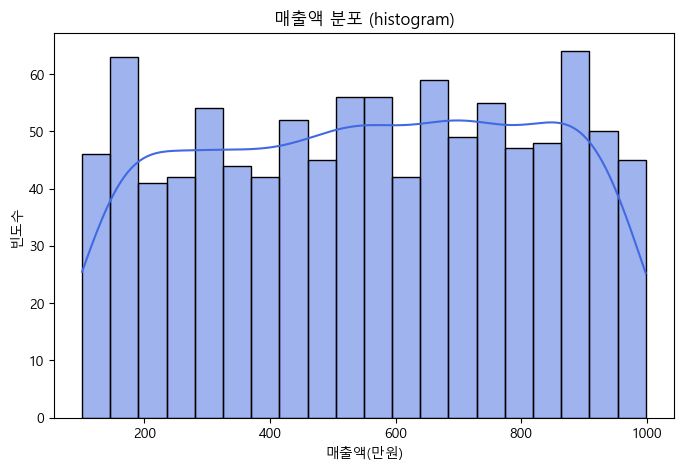

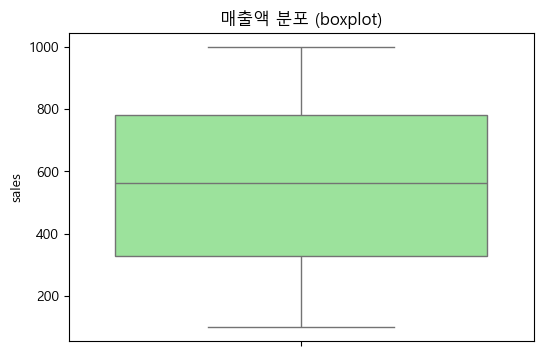

In [21]:
from matplotlib import font_manager, rc

plt.rcParams['font.family'] = 'Malgun Gothic' # 한글 폰트 지정
plt.rcParams['axes.unicode_minus'] = False # 마이너스 부호 깨짐 방지

plt.figure(figsize=(8,5))
sns.histplot(df.sales, bins=20, kde=True, color='royalblue')
plt.title('매출액 분포 (histogram)')
plt.xlabel('매출액(만원)')
plt.ylabel('빈도수')

plt.figure(figsize=(6,4))
sns.boxplot(y='sales', data=df, color='lightgreen')
plt.title('매출액 분포 (boxplot)')
plt.show()

In [22]:
df['date'] = pd.to_datetime(df.date)

In [24]:
df_month = df.groupby(
    df['date'].dt.to_period('M')
).sum(numeric_only = True)
df_month.index = df_month.index.astype(str)

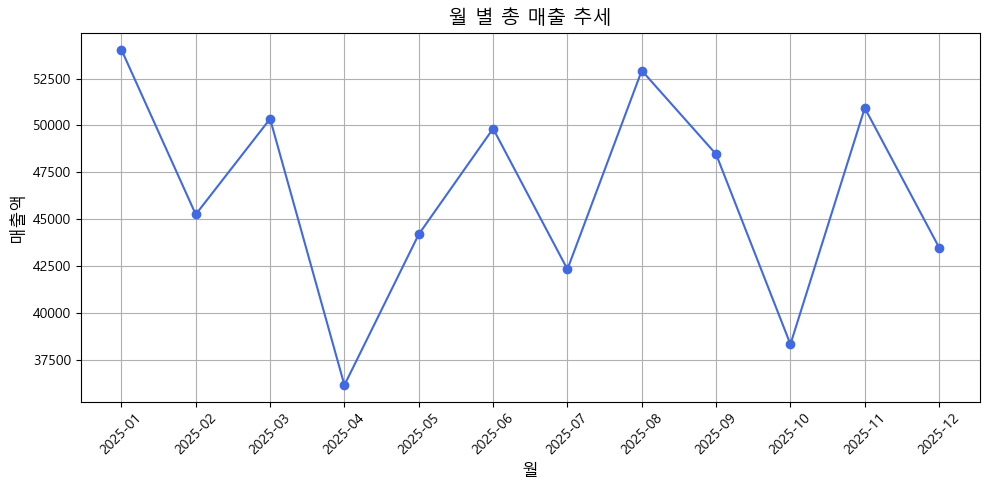

In [29]:
plt.figure(figsize=(10,5))
plt.plot(df_month.index, df_month['sales'], marker='o', color='royalblue')
plt.title('월 별 총 매출 추세', fontsize=14)
plt.xlabel('월', fontsize=12)
plt.ylabel('매출액', fontsize=12)
plt.grid(True) # 격자 표시
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

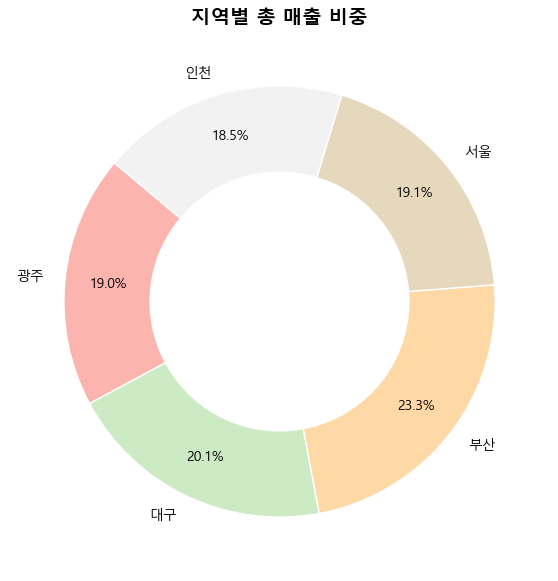

In [31]:
## 지역별 평균 매출 비교 (범주형 비교)
region_sales = df.groupby('region')['sales'].sum()
colors = plt.cm.Pastel1(np.linspace(0, 1, len(region_sales)))

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    region_sales,
    labels=region_sales.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.8,
    wedgeprops=dict(width=0.4, edgecolor='w')
)
ax.set_title('지역별 총 매출 비중', fontsize=14, fontweight='bold')
plt.show()

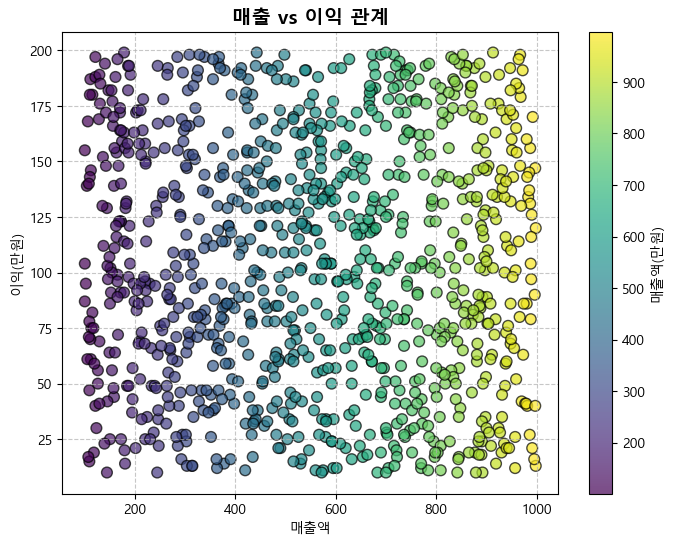

In [33]:
## 제품 별 매출 - 이익 상관관계 (두 변수 관계) - 산점도 그래프 뽑아보기
plt.figure(figsize=(8,6)) # 앞:세로, 뒤:가로 사이즈 지정한다.
scatter = plt.scatter(df.sales, df.profit, c=df.sales, cmap='viridis', s=60, alpha=0.7, edgecolor='black') # 산점도 그래프는 스캐터로 그린다.

plt.colorbar(scatter, label='매출액(만원)')
plt.title('매출 vs 이익 관계', fontsize=14, fontweight='bold')
plt.xlabel('매출액')
plt.ylabel('이익(만원)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

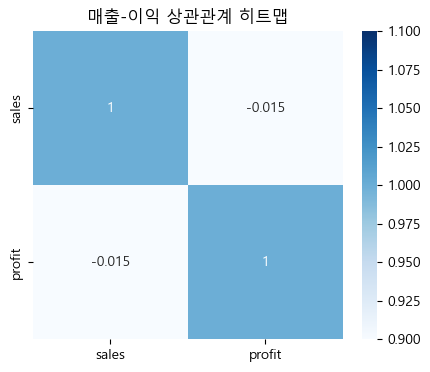

In [72]:
##
plt.figure(figsize=(5,4))
corr = df[['sales','profit']].corr()

sns.heatmap(corr, annot=True, cmap='Blues', vmin=1, vmax=1)

plt.title('매출-이익 상관관계 히트맵')
plt.show()

## 지역별 월간 매출 추세 (plotly 대화형 그래프 - 추세, 트렌드 비교)

In [39]:
! pip install plotly
! pip install folium


   ------------- -------------------------- 1/3 [branca]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   ---------------------------------------- 3/3 [folium]



In [50]:
! pip install plotly

In [51]:
! pip install folium

In [57]:
import plotly.express as px

In [58]:
## 월별+지역별 총 매출
df['month'] = df['date'].dt.strftime('%Y-%m')
df_month_region = df.groupby(['month','region'])['sales'].sum().reset_index()

## Plotly 그래프
fig = px.line(
    df_month_region,
    x='month',
    y='sales',
    color='region',
    title='지역별 월간 매출 추세',
    markers=True
)

fig.update_layout(
    xaxis_title='월',
    yaxis_title='매출액(만원)',
    legend_title='지역'
)
fig.show()

## 지역별 평균 매출 지도 시각화(Folium) - 맵/지도로 표현할 것이다. (folium 활용)

In [59]:
## 지역별 평균 매출을 맵으로 표현해서 지역 매출의 양에 의해 시각적 표현을 할 것이다.
import folium

In [70]:
## 지역별 평균 매출
region_sales = df.groupby('region')['sales'].mean()

## 지역별 위도/경도 표시
region_coords = {
    '서울': [37.5665, 126.9780],
    '부산': [35.1796, 129.0756],
    '대구': [35.8714, 128.6014],
    '광주': [35.1595, 126.8526],
    '인천': [37.4563, 126.7052]
}

## 지도 생성 (오, 신기하다!)
m = folium.Map(location=[36.5, 127.8], zoom_start=7)

## 각 지역에 CircleMarker 추가
for region, avg_sales in region_sales.items():
    folium.CircleMarker(
        location=region_coords[region], 
        radius=avg_sales/50, # 매출 크기에 비례한 원의 크기 지정!!
        color='black',
        fill=True,
        fill_opacity=0.6,
        popup=f"{region}: {avg_sales:.1f}만원"
    ).add_to(m)

# 지도 저장 및 표시
m.save('sales_map.html')
m

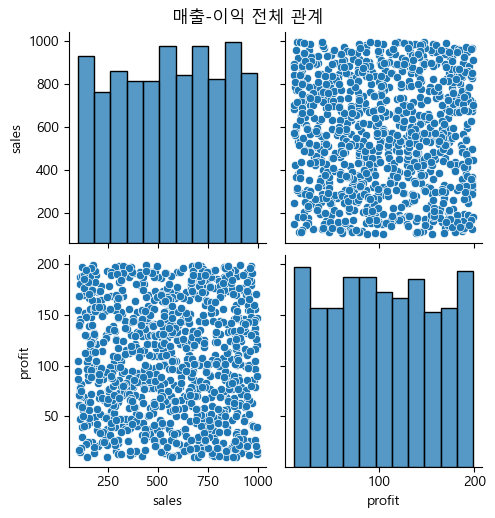

In [74]:
## 각 조합 별 산점도를 자동으로 그려주고, 데이터 간 상관 ㅇㄱ
sns.pairplot(df[['sales','profit']], kind='scatter')
plt.suptitle('매출-이익 전체 관계', y=1.02)
plt.show()